In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [5]:
df = pd.read_csv("PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 145366
Columns: 2


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


In [9]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [10]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[us]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 2.2 MB


In [12]:
print("Start date:", df["Datetime"].min())
print("End date:", df["Datetime"].max())

Start date: 2002-01-01 01:00:00
End date: 2018-08-03 00:00:00


In [13]:
duration = (
    df["Datetime"].max()
    - df["Datetime"].min()
)
print("Dataset duration:", duration)

Dataset duration: 6057 days 23:00:00


In [14]:
df = df.sort_values("Datetime").reset_index(drop=True)

In [16]:
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [17]:
df[df.duplicated()]

,Datetime,PJME_MW


In [18]:
duplicate_timestamps = df["Datetime"].duplicated().sum()
print(
    "Duplicate timestamps:",
    duplicate_timestamps
)

Duplicate timestamps: 4


In [19]:
df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime").head(20)

,Datetime,PJME_MW
112487,2014-11-02 02:00:00,23755.0
112488,2014-11-02 02:00:00,22935.0
121223,2015-11-01 02:00:00,21567.0
121224,2015-11-01 02:00:00,21171.0
130127,2016-11-06 02:00:00,20795.0
130128,2016-11-06 02:00:00,21692.0
138863,2017-11-05 02:00:00,21236.0
138864,2017-11-05 02:00:00,20666.0


In [20]:
print(df.isnull().sum())

Datetime    0
PJME_MW     0
dtype: int64


In [23]:
df["PJME_MW"].dtype

dtype('float64')

In [24]:
time_difference = df["Datetime"].diff()

In [25]:
time_difference.value_counts().head(10)

Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64

In [26]:
irregular_intervals = df[
    time_difference.notna() &
    (time_difference != pd.Timedelta(hours=1))
]
print(
    "Number of irregular intervals:",
    len(irregular_intervals)
)

Number of irregular intervals: 34


In [27]:
irregular_intervals.head(20)

,Datetime,PJME_MW
2306,2002-04-07 04:00:00,24487.0
7176,2002-10-27 03:00:00,20605.0
11040,2003-04-06 04:00:00,22902.0
15910,2003-10-26 03:00:00,20641.0
19774,2004-04-04 04:00:00,23208.0
24812,2004-10-31 03:00:00,20585.0
28508,2005-04-03 04:00:00,23414.0
33546,2005-10-30 03:00:00,23302.0
37242,2006-04-02 04:00:00,20833.0
42280,2006-10-29 03:00:00,23310.0


In [28]:
expected_timestamps = pd.date_range(
    start=df["Datetime"].min(),
    end=df["Datetime"].max(),
    freq="h"
)

In [30]:
missing_timestamps = expected_timestamps.difference(df["Datetime"])

In [31]:
print(
    "Number of missing timestamps:",
    len(missing_timestamps)
)

Number of missing timestamps: 30


In [34]:
print(missing_timestamps[:20])

DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00',
               '2007-03-11 03:00:00', '2007-11-04 02:00:00',
               '2008-03-09 03:00:00', '2008-11-02 02:00:00',
               '2009-03-08 03:00:00', '2009-11-01 02:00:00',
               '2010-03-14 03:00:00', '2010-11-07 02:00:00',
               '2010-12-10 00:00:00', '2011-03-13 03:00:00'],
              dtype='datetime64[us]', freq=None)


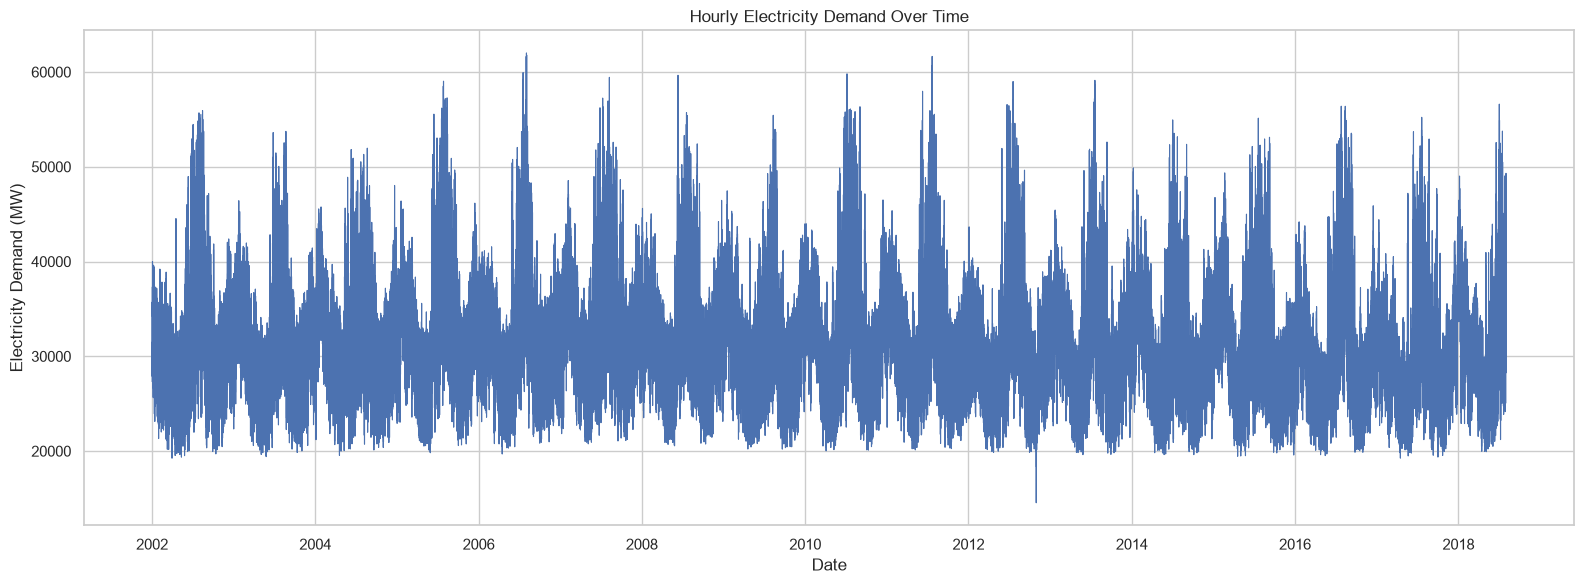

In [36]:
plt.figure(figsize=(16, 6))
plt.plot(
    df["Datetime"],
    df["PJME_MW"],
    linewidth=0.8
)
plt.title("Hourly Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")
plt.tight_layout()
plt.show()

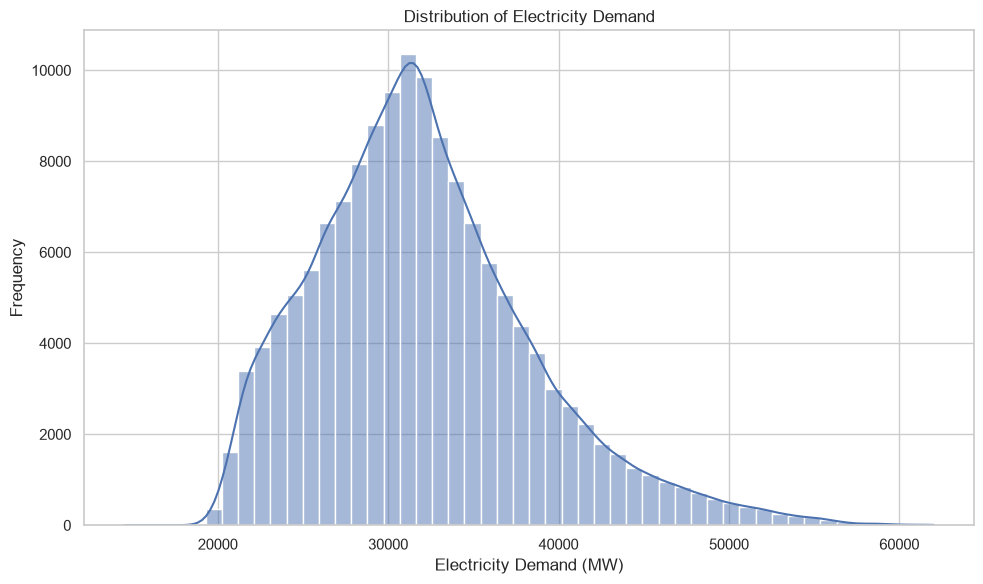

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(
    df["PJME_MW"].dropna(),
    bins=50,
    kde=True
)
plt.title("Distribution of Electricity Demand")
plt.xlabel("Electricity Demand (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

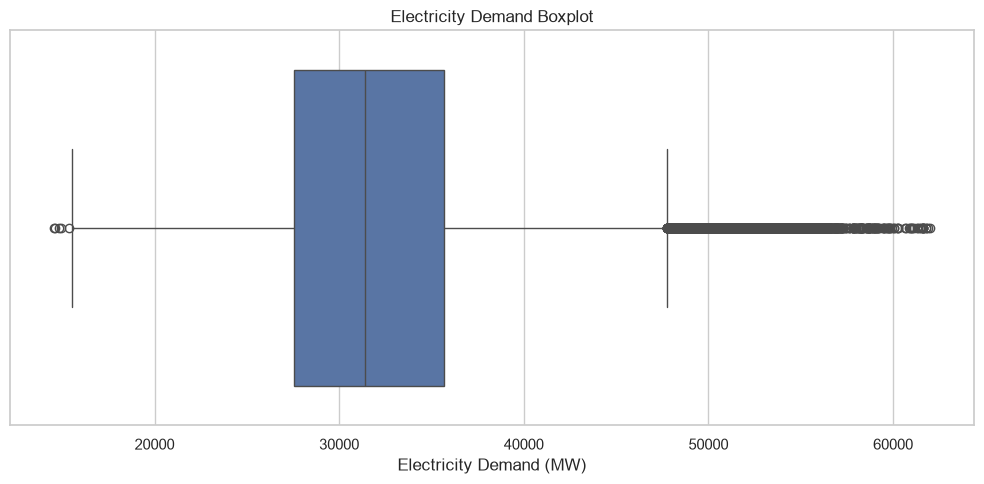

In [38]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x=df["PJME_MW"]
)
plt.title("Electricity Demand Boxplot")
plt.xlabel("Electricity Demand (MW)")
plt.tight_layout()
plt.show()

In [39]:
df["Hour"] = df["Datetime"].dt.hour

In [40]:
hourly_demand = (
    df.groupby("Hour")["PJME_MW"]
    .mean()
)
hourly_demand

Hour
0     29523.611194
1     27535.589964
2     26344.055207
3     25679.097666
4     25414.924728
5     25749.431000
6     27162.853912
7     29611.046880
8     31490.827831
9     32628.888247
10    33497.403433
11    34197.643117
12    34588.618356
13    34759.571146
14    34916.601684
15    34940.669693
16    35065.392209
17    35596.051502
18    36421.931496
19    36426.629911
20    36106.840211
21    35741.057280
22    34453.149884
23    32047.501486
Name: PJME_MW, dtype: float64

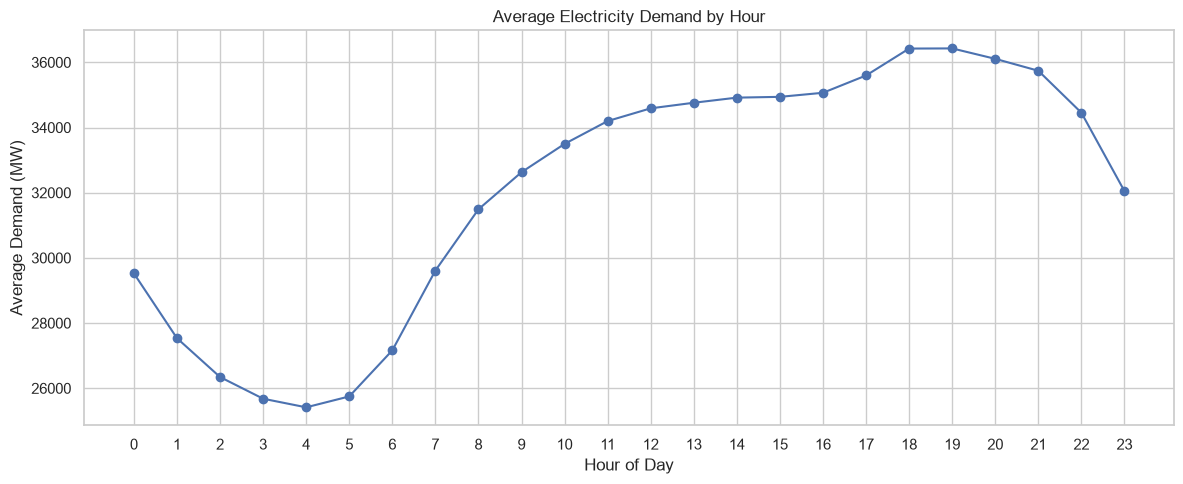

In [41]:
plt.figure(figsize=(12, 5))
plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)
plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [42]:
df["DayOfWeek"] = df["Datetime"].dt.dayofweek

In [43]:
weekly_demand = (
    df.groupby("DayOfWeek")["PJME_MW"]
    .mean()
)
weekly_demand

DayOfWeek
0    32672.028420
1    33272.265746
2    33261.497498
3    33085.857727
4    32688.097688
5    30162.880588
6    29411.869930
Name: PJME_MW, dtype: float64

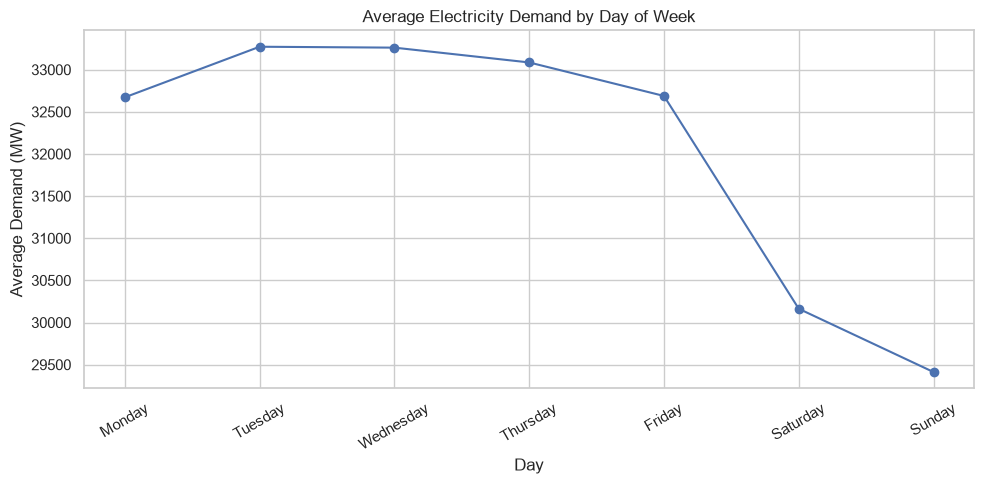

In [44]:
day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
plt.figure(figsize=(10, 5))
plt.plot(
    weekly_demand.index,
    weekly_demand.values,
    marker="o"
)
plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(
    range(7),
    day_names,
    rotation=30
)
plt.tight_layout()
plt.show()

In [45]:
df["Month"] = df["Datetime"].dt.month

In [46]:
monthly_demand = (
    df.groupby("Month")["PJME_MW"]
    .mean()
)
monthly_demand

Month
1     34343.246462
2     33434.972049
3     30514.903609
4     27863.339354
5     28695.362113
6     33811.799183
7     37881.972881
8     36595.959675
9     31484.054688
10    28119.228675
11    29328.733872
12    32676.247669
Name: PJME_MW, dtype: float64

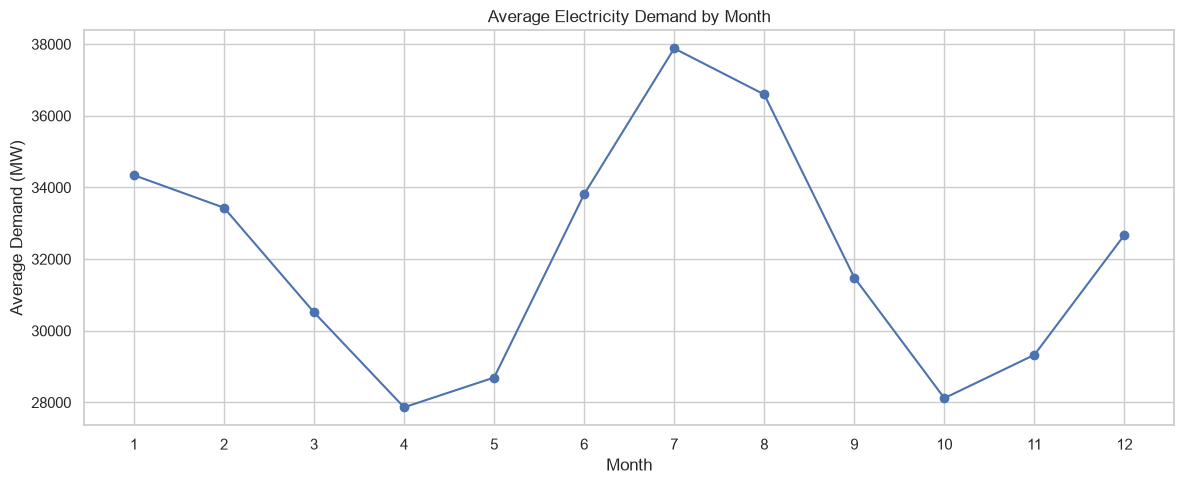

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)
plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [48]:
df["Year"] = df["Datetime"].dt.year

In [49]:
yearly_demand = (
    df.groupby("Year")["PJME_MW"]
    .mean()
)
yearly_demand

Year
2002    31565.617106
2003    31698.758621
2004    32270.434867
2005    33310.478648
2006    32409.269696
2007    33613.468600
2008    32929.593373
2009    31851.533683
2010    33101.172662
2011    32368.308518
2012    31440.107265
2013    31706.525120
2014    31496.406963
2015    31709.394178
2016    31337.833106
2017    30650.911644
2018    31782.598715
Name: PJME_MW, dtype: float64

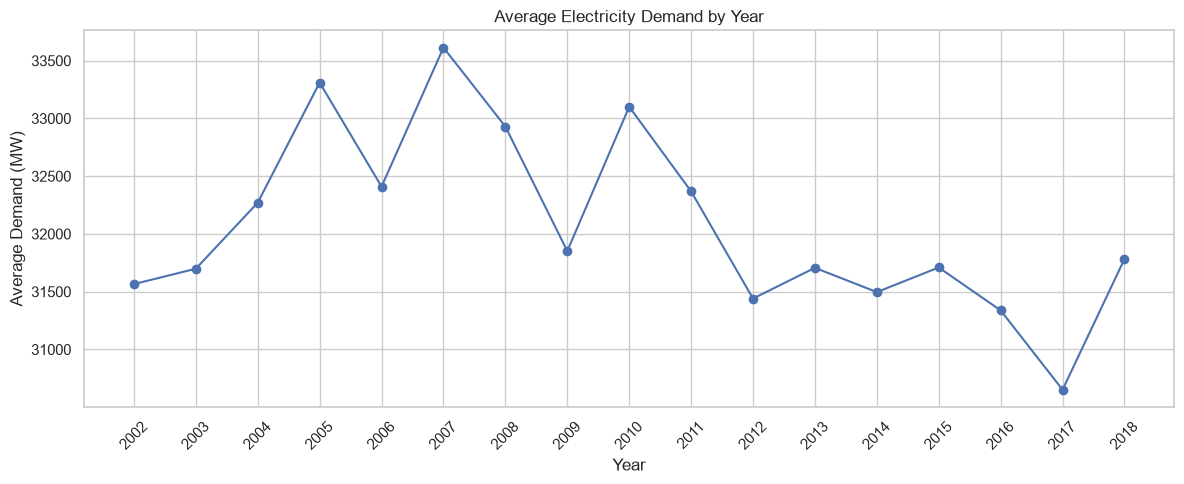

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(
    yearly_demand.index,
    yearly_demand.values,
    marker="o"
)
plt.title("Average Electricity Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Demand (MW)")
plt.xticks(
    yearly_demand.index,
    rotation=45
)
plt.tight_layout()
plt.show()

In [51]:
hour_day = df.pivot_table(
    values="PJME_MW",
    index="DayOfWeek",
    columns="Hour",
    aggfunc="mean"
)

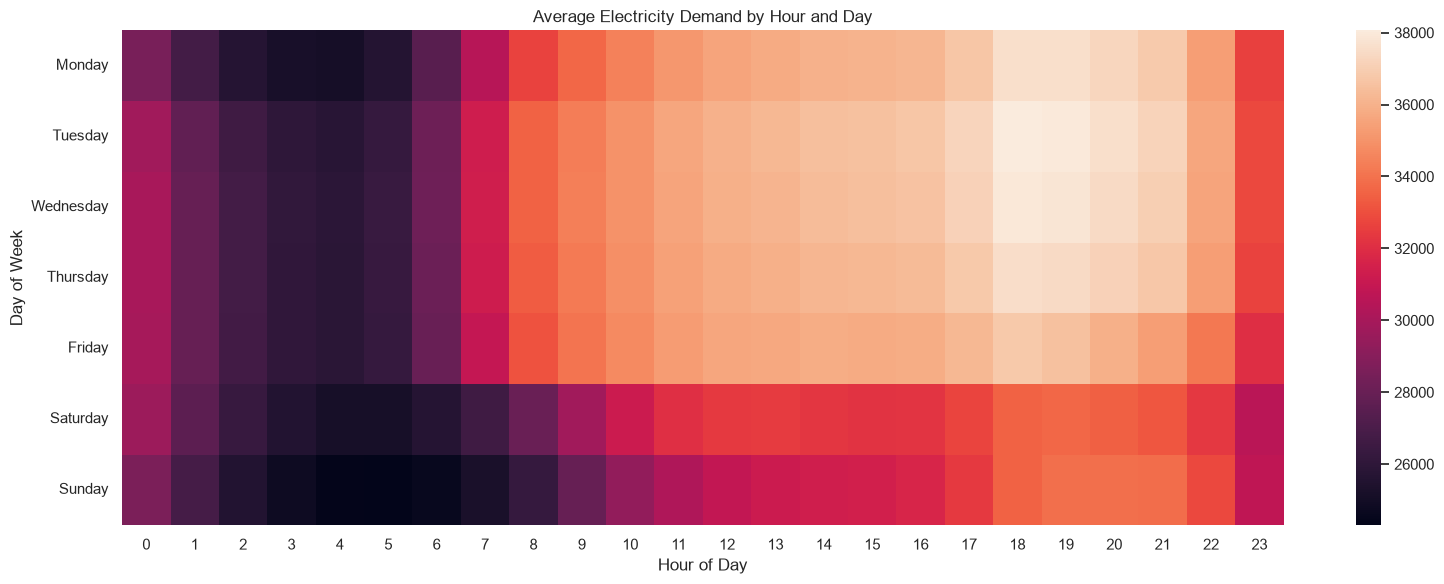

In [52]:
plt.figure(figsize=(16, 6))
sns.heatmap(
    hour_day,
    xticklabels=range(24),
    yticklabels=day_names
)
plt.title(
    "Average Electricity Demand by Hour and Day"
)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

In [53]:
peak_demand = df.nlargest(
    20,
    "PJME_MW"
)
peak_demand[
    ["Datetime", "PJME_MW"]
]

,Datetime,PJME_MW
40183,2006-08-02 17:00:00,62009.0
40182,2006-08-02 16:00:00,61909.0
40207,2006-08-03 17:00:00,61796.0
40206,2006-08-03 16:00:00,61770.0
83730,2011-07-22 15:00:00,61646.0
40159,2006-08-01 17:00:00,61643.0
40181,2006-08-02 15:00:00,61641.0
40184,2006-08-02 18:00:00,61610.0
83731,2011-07-22 16:00:00,61608.0
83729,2011-07-22 14:00:00,61532.0


In [54]:
max_row = df.loc[
    df["PJME_MW"].idxmax()
]
print(max_row)

Datetime     2006-08-02 17:00:00
PJME_MW                  62009.0
Hour                          17
DayOfWeek                      2
Month                          8
Year                        2006
Name: 40183, dtype: object


In [55]:
lowest_demand = df.nsmallest(
    20,
    "PJME_MW"
)
lowest_demand[
    ["Datetime", "PJME_MW"]
]

,Datetime,PJME_MW
94901,2012-10-30 04:00:00,14544.0
94900,2012-10-30 03:00:00,14586.0
94902,2012-10-30 05:00:00,14821.0
94899,2012-10-30 02:00:00,14955.0
94898,2012-10-30 01:00:00,15390.0
94903,2012-10-30 06:00:00,15526.0
94897,2012-10-30 00:00:00,15919.0
94904,2012-10-30 07:00:00,16688.0
94896,2012-10-29 23:00:00,17422.0
94905,2012-10-30 08:00:00,17734.0


In [56]:
Q1 = df["PJME_MW"].quantile(0.25)
Q3 = df["PJME_MW"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [57]:
outliers = df[
    (df["PJME_MW"] < lower_bound) |
    (df["PJME_MW"] > upper_bound)
]
print(
    "Potential outliers:",
    len(outliers)
)

Potential outliers: 3455


In [58]:
outlier_percentage = (
    len(outliers) / len(df)
) * 100

print(
    "Outlier percentage:",
    outlier_percentage
)

Outlier percentage: 2.3767593522556854


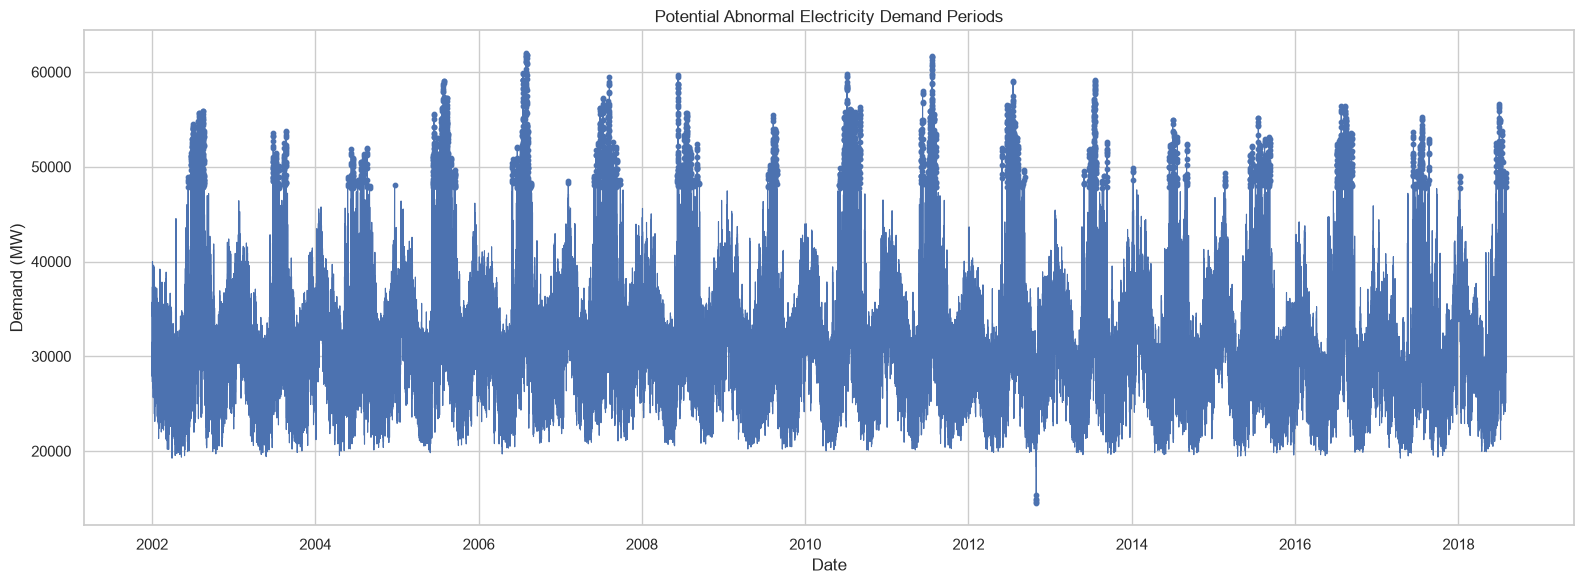

In [59]:
plt.figure(figsize=(16, 6))
plt.plot(
    df["Datetime"],
    df["PJME_MW"],
    linewidth=0.8
)
plt.scatter(
    outliers["Datetime"],
    outliers["PJME_MW"],
    s=10
)
plt.title(
    "Potential Abnormal Electricity Demand Periods"
)
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.tight_layout()
plt.show()